In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

# 06 — Unconventional Axes: Material Sweeps & Custom Parameter Maps

One of the most powerful features of this library is that **any** `ProcessParameters` field
or **any** `Material` property can serve as a sweep axis. This notebook demonstrates two
advanced use cases: a scan speed vs absorptivity map (exploring material/wavelength effects),
and a thermal conductivity vs laser power map (exploring alloy selection).

---

## Section 1 — Imports and Context

The key architectural insight: because `Material` properties are now NumPy arrays, you can
pass a *vector* of absorptivity values into `Material(...)` and pair it with a matching
`scan_speed` vector in `ProcessParameters`. The `MeltPool` and `PrintabilitySpace` will
broadcast correctly across both.

When the sweep axis is a **Material property** (not a `ProcessParameters` field), the
`plot_2d()` bridge cannot be used directly — it only resolves `ProcessParameters` names.
Instead, we extract `space.defect_map` and plot it manually with Matplotlib, giving full
control over axis labels and aesthetics.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter

from lpbf_maps import Material, ProcessParameters, MeltPool, PrintabilitySpace
from lpbf_maps.defects import (
    DefectSuite,
    LackOfFusionCriterion,
    BallingPlateauRayleighCriterion,
    KeyholeGanCriterion,
)

# Shared colour palette for defect maps across all sections
COLORS = {
    0: '#140b34',  # Safe Zone
    1: '#f6d746',  # Balling
    2: '#e55c30',  # Lack of Fusion
    3: '#84206b',  # Keyhole
}


def build_standard_suite():
    """Helper: returns a DefectSuite with the standard three criteria."""
    suite = DefectSuite()
    suite.add(1, BallingPlateauRayleighCriterion())
    suite.add(2, LackOfFusionCriterion())
    suite.add(3, KeyholeGanCriterion())
    return suite


print('Imports complete.')

Imports complete.


---

## Section 2 — Scan Speed vs Absorptivity Map (Ti-6Al-4V)

**Goal:** How does the printability window shift as absorptivity changes (simulating different
surface conditions or powder morphologies)?

Real-world absorptivity for Ti-6Al-4V at 1064 nm spans roughly 0.30–0.80 depending on
surface oxidation, powder particle size, and degree of sintering. This map reveals how
sensitive the safe zone boundaries are to that uncertainty.

**Broadcasting strategy:**
- `absorptivity` is a **row vector** `(1, 30)` — varies across the columns.
- `scan_speed` is a **column vector** `(30, 1)` — varies down the rows.
- NumPy broadcast rules expand both to `(30, 30)` during physics evaluation.

In [3]:
# Row vector: absorptivity varies across columns  (dimensionless)
absorptivities = np.linspace(0.3, 0.8, 30)[np.newaxis, :]   # shape: (1, 30)

# Column vector: scan_speed varies down rows         [m/s]
scan_speeds = np.linspace(0.3, 2.5, 30)[:, np.newaxis]       # shape: (30, 1)

# Create a Ti64-like material with an array absorptivity
mat = Material(
    name='Ti64_absorptivity_sweep',
    density=4250,
    specific_heat=745,
    thermal_conductivity=38,
    melting_temperature=1877,
    boiling_temperature=3560,
    absorptivity=absorptivities    # <-- array!
)

params = ProcessParameters(
    laser_power=200.0,           # fixed laser power [W]
    scan_speed=scan_speeds,      # swept down rows   [m/s]
    beam_radius=40e-6,           # [m]
    hatch_spacing=80e-6,         # [m]
    layer_thickness=30e-6        # [m]
)

print(f'Absorptivity array shape : {mat.absorptivity.shape}')   # -> (1, 30)
print(f'ProcessParameters shape  : {params.shape}')             # -> (30, 1)

pool = MeltPool(mat, params)
suite = build_standard_suite()
space = DefectSuite  # placeholder — replaced below

space = PrintabilitySpace(pool, suite)
space.evaluate()

print(f'Defect map shape         : {space.defect_map.shape}')   # -> (30, 30)

Absorptivity array shape : (1, 30)
ProcessParameters shape  : (30, 1)
Defect map shape         : (30, 30)


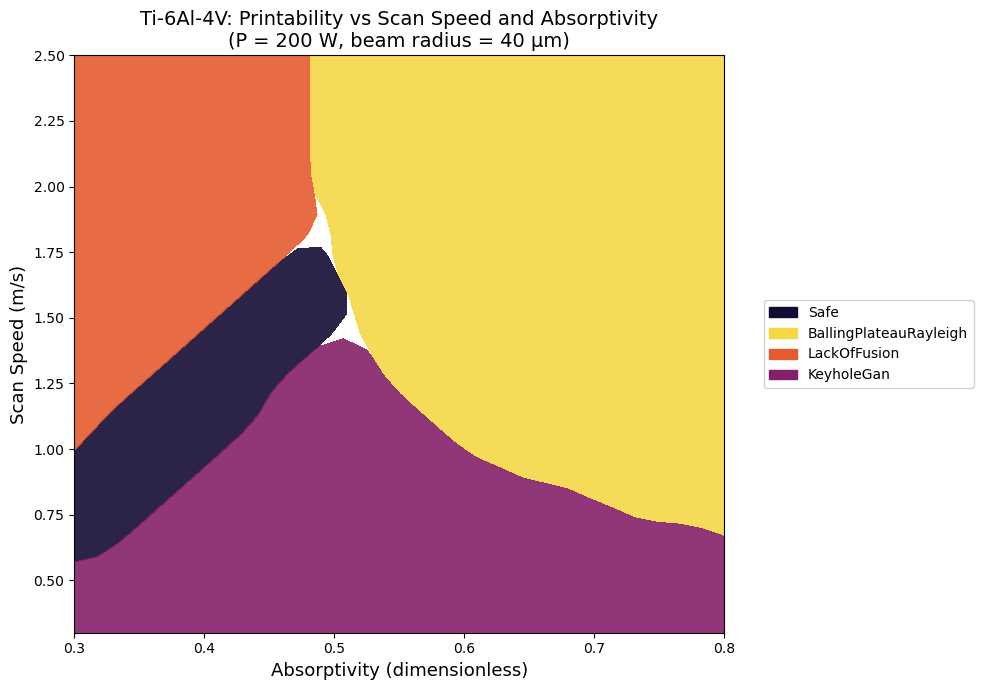

In [4]:
# Build the axis grids manually (absorptivity is on Material, not ProcessParameters)
absorptivity_grid, scan_speed_grid = np.meshgrid(
    mat.absorptivity.ravel(),   # x-axis: 30 absorptivity values
    scan_speeds.ravel()         # y-axis: 30 scan speed values
)

fig, ax = plt.subplots(figsize=(10, 7))

# Plot each defect region using the same Gaussian-smoothed contour technique
for uid in sorted(space.defect_labels):
    binary_mask = (space.defect_map == uid).astype(float)
    smoothed = gaussian_filter(binary_mask, sigma=1.0)
    ax.contourf(absorptivity_grid, scan_speed_grid, smoothed,
                levels=[0.5, 2.0], colors=[COLORS[uid]], alpha=0.9)

patches = [
    mpatches.Patch(color=COLORS[uid], label=space.defect_labels[uid])
    for uid in sorted(space.defect_labels)
]
ax.legend(handles=patches, bbox_to_anchor=(1.05, 0.5), loc='center left', framealpha=0.9)

ax.set_xlabel('Absorptivity (dimensionless)', fontsize=13)
ax.set_ylabel('Scan Speed (m/s)', fontsize=13)
ax.set_title(
    'Ti-6Al-4V: Printability vs Scan Speed and Absorptivity\n'
    '(P = 200 W, beam radius = 40 µm)',
    fontsize=14
)
plt.tight_layout()
plt.show()

---

## Section 3 — Thermal Conductivity vs Laser Power Map (Alloy Design)

**Goal:** Explore how alloy thermal conductivity (a key alloy-selection parameter) shifts the
printability window at different laser powers.

Thermal conductivity *k* ranges from ~10 W/(m·K) (low-conductivity superalloys) to ~60 W/(m·K)
(some tool steels). Higher *k* removes heat faster, reducing melt pool size — which can push
the process into the lack-of-fusion regime unless power is increased to compensate.

**Broadcasting strategy:**
- `thermal_conductivity` is a **row vector** `(1, 25)` on the Material.
- `laser_power` is a **column vector** `(25, 1)` in ProcessParameters.
- Broadcast shape: `(25, 25)`.

In [6]:
# Row vector: thermal conductivity varies across columns  [W/(m*K)]
thermal_conductivities = np.linspace(10, 60, 25)[np.newaxis, :]  # shape: (1, 25)

# Column vector: laser power varies down rows              [W]
laser_powers = np.linspace(100, 400, 25)[:, np.newaxis]           # shape: (25, 1)

# Generic metallic alloy with swept thermal conductivity
mat_alloy = Material(
    name='Generic_alloy_k_sweep',
    density=7900,
    specific_heat=500,
    thermal_conductivity=thermal_conductivities,   # <-- array!
    melting_temperature=1673,
    boiling_temperature=3134,
    absorptivity=0.50
)

params_alloy = ProcessParameters(
    laser_power=laser_powers,    # swept down rows  [W]
    scan_speed=1.0,              # fixed            [m/s]
    beam_radius=50e-6,           # [m]
    hatch_spacing=90e-6,         # [m]
    layer_thickness=35e-6        # [m]
)

# Derived thermal_diffusivity shape follows k:
print(f'thermal_conductivity shape : {mat_alloy.thermal_conductivity.shape}')  # -> (1, 25)
print(f'thermal_diffusivity shape  : {mat_alloy.thermal_diffusivity.shape}')   # -> (1, 25)
print(f'ProcessParameters shape    : {params_alloy.shape}')                     # -> (25, 1)

thermal_conductivity shape : (1, 25)
thermal_diffusivity shape  : (1, 25)
ProcessParameters shape    : (25, 1)


In [7]:
pool_alloy = MeltPool(mat_alloy, params_alloy)
suite_alloy = build_standard_suite()
space_alloy = PrintabilitySpace(pool_alloy, suite_alloy)
space_alloy.evaluate()

print(f'Defect map shape : {space_alloy.defect_map.shape}')  # -> (25, 25)

Defect map shape : (25, 25)


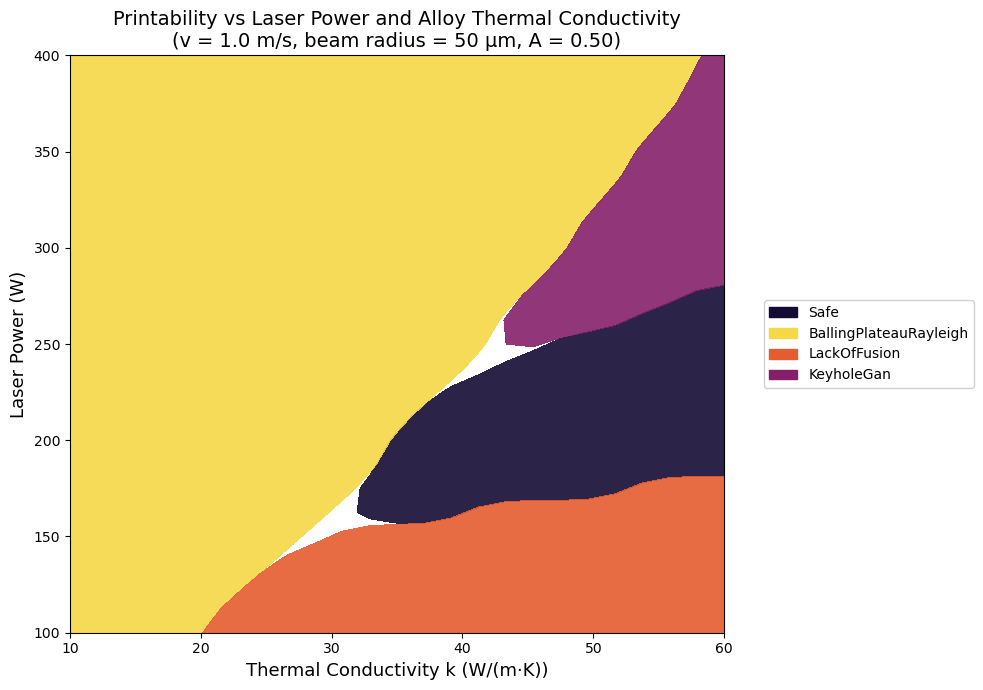

In [8]:
# Build axis grids manually
k_grid, P_grid = np.meshgrid(
    thermal_conductivities.ravel(),   # x-axis: conductivity values
    laser_powers.ravel()              # y-axis: laser power values
)

fig, ax = plt.subplots(figsize=(10, 7))

for uid in sorted(space_alloy.defect_labels):
    binary_mask = (space_alloy.defect_map == uid).astype(float)
    smoothed = gaussian_filter(binary_mask, sigma=1.0)
    ax.contourf(k_grid, P_grid, smoothed,
                levels=[0.5, 2.0], colors=[COLORS[uid]], alpha=0.9)

patches = [
    mpatches.Patch(color=COLORS[uid], label=space_alloy.defect_labels[uid])
    for uid in sorted(space_alloy.defect_labels)
]
ax.legend(handles=patches, bbox_to_anchor=(1.05, 0.5), loc='center left', framealpha=0.9)

ax.set_xlabel('Thermal Conductivity k (W/(m·K))', fontsize=13)
ax.set_ylabel('Laser Power (W)', fontsize=13)
ax.set_title(
    'Printability vs Laser Power and Alloy Thermal Conductivity\n'
    '(v = 1.0 m/s, beam radius = 50 µm, A = 0.50)',
    fontsize=14
)
plt.tight_layout()
plt.show()

---

## Section 4 — Hagen-Rubens Absorptivity Map (NiTi Wavelength Sweep)

**Goal:** Use `Material.calculate_absorptivity()` to explore how different laser wavelengths
affect the printability of NiTi.

The **Hagen-Rubens approximation** relates absorptivity to electrical resistivity and laser
wavelength:

$$A \approx 0.365 \sqrt{\rho_e / \lambda}$$

where $\rho_e$ is the electrical resistivity [\u03a9·m] and $\lambda$ is the laser wavelength [m].

The three wavelengths below correspond to commercially relevant laser systems:

| Wavelength | Laser type | Typical L-PBF use |
|---|---|---|
| 532 nm | Green (frequency-doubled Nd:YAG) | High-reflectivity metals |
| 1064 nm | Standard Nd:YAG / Yb:YAG fibre | Mainstream L-PBF |
| 1550 nm | Telecom fibre (Er-doped) | Emerging long-wavelength systems |

In [9]:
# Load NiTi — it carries electrical_resistivity in the database
niti = Material.from_library('NiTi_Sheikh')
print(f'NiTi electrical resistivity : {float(niti.electrical_resistivity):.2e} Ω·m')
print(f'NiTi default absorptivity   : {float(niti.absorptivity):.3f}')

wavelengths = {
    '532 nm (green)': 0.532e-6,
    '1064 nm (Nd:YAG)': 1.064e-6,
    '1550 nm (telecom)': 1.550e-6,
}

# Scan speed 1D sweep (column vector) shared across all wavelengths
scan_speeds_1d = np.linspace(0.3, 2.5, 25)[:, np.newaxis]  # shape: (25, 1)

results_table = []

for label, wl in wavelengths.items():
    # Clone the material and compute absorptivity via Hagen-Rubens
    mat_wl = Material.from_library('NiTi_Sheikh')
    mat_wl.calculate_absorptivity(wavelength=wl, method='hagen-rubens')
    absorptivity_val = float(mat_wl.absorptivity)

    params_wl = ProcessParameters(
        laser_power=200.0,
        scan_speed=scan_speeds_1d,
        beam_radius=40e-6,
        hatch_spacing=80e-6,
        layer_thickness=30e-6
    )

    pool_wl = MeltPool(mat_wl, params_wl)
    suite_wl = build_standard_suite()
    space_wl = PrintabilitySpace(pool_wl, suite_wl)
    space_wl.evaluate()

    # Count safe scan speed points
    safe_mask = space_wl.defect_map == 0
    safe_speeds = scan_speeds_1d.ravel()[safe_mask.ravel()]
    if len(safe_speeds) > 0:
        speed_range = f'{safe_speeds.min():.2f}–{safe_speeds.max():.2f} m/s'
    else:
        speed_range = 'None'

    results_table.append((label, absorptivity_val, speed_range))
    print(f'{label:22s} | A = {absorptivity_val:.3f} | Safe scan speed range: {speed_range}')

NiTi electrical resistivity : 8.20e-08 Ω·m
NiTi default absorptivity   : 0.560
532 nm (green)         | A = 0.143 | Safe scan speed range: 0.30–0.39 m/s
1064 nm (Nd:YAG)       | A = 0.101 | Safe scan speed range: None
1550 nm (telecom)      | A = 0.084 | Safe scan speed range: None


In [10]:
# Display as a formatted summary table
print('\n' + '='*70)
print(f'{"Laser wavelength":22s} | {"Absorptivity":12s} | {"Safe speed range":20s}')
print('-'*70)
for label, absorptivity, speed_range in results_table:
    print(f'{label:22s} | {absorptivity:12.3f} | {speed_range:20s}')
print('='*70)
print('\nConclusion: shorter wavelengths yield higher absorptivity,')
print('widening the safe processing window at equivalent laser power.')


Laser wavelength       | Absorptivity | Safe speed range    
----------------------------------------------------------------------
532 nm (green)         |        0.143 | 0.30–0.39 m/s       
1064 nm (Nd:YAG)       |        0.101 | None                
1550 nm (telecom)      |        0.084 | None                

Conclusion: shorter wavelengths yield higher absorptivity,
widening the safe processing window at equivalent laser power.
